# SI'26 – Week 2: Image Preprocessing + Testing Existing OCR Tools
**Author: Qandeel Asim**
**Student ID: 2023-BS-AI-037**
**Track: Urdu OCR Tool — Code Saviours Summer Internship 2026 (SI-26)**

---

## How this notebook connects to Week 1

Week 1 (`SI26_Week1_Qandeel.ipynb`) built a labeled Urdu OCR dataset of **265 images**
from 8 sources (UTRSet-Real, synthetic renders, 3 kinds of augmentation, synthetic
books, synthetic signboards, and manual newspaper screenshots), and saved everything as:

- `data/raw/<category>/...` — the actual image files
- `data/labels.csv` — master file with columns `image, text, source, split`
- `data/train.csv`, `data/test.csv` — the 80/20 split
- `my_dataset_final.zip` — the whole `data/` folder zipped up for portability

**This notebook (Week 2) picks up exactly where Week 1 left off.** It reads
`data/labels.csv` directly — the same file, the same column names, the same
image paths — so nothing needs to be re-collected or renamed. If you're running
this in a **new** Colab session (Week 1's files aren't in memory anymore), Step 0
below lets you re-load them from `my_dataset_final.zip`.

## What this notebook does

1. **Load** the Week 1 dataset (`data/labels.csv` + `data/raw/`).
2. **Preprocess** every image (grayscale → denoise → binarize → deskew → resize)
   and save the results into `data/processed/`, mirroring the same source
   subfolders Week 1 used.
3. **Test Tesseract OCR** — an existing, off-the-shelf tool — on Urdu text, on
   both raw and preprocessed images, and score it against the Week 1 ground-truth
   labels using Character Error Rate (CER).
4. **Gap analysis** — explain in plain English why Tesseract struggles with Urdu
   Nastaliq script, and auto-generate a Markdown section ready to paste into
   `README.md`.

> **Deliverables (Submit by Friday, July 10):**
> - GitHub link: `SI26-Week2-Qandeel.ipynb`
> - GitHub link: `data/processed/` folder with preprocessed images
> - `README.md` updated with the gap analysis (Tesseract results + why it fails on Urdu)

Run the cells **in order, top to bottom** — later cells depend on variables and
functions defined earlier, exactly like Week 1.


## Step 0: Load the Week 1 Dataset

Two scenarios are handled automatically:

- **Same Colab session as Week 1** (you just ran `SI26_Week1_Qandeel.ipynb` above
  this notebook, or re-ran it earlier today): `data/labels.csv` already exists on
  disk, so nothing needs to be uploaded — the check below will just confirm it's there.
- **Fresh Colab session**: `data/labels.csv` won't exist yet. The cell will ask you
  to upload `my_dataset_final.zip` (the file Week 1's last step created) and unzip
  it automatically, recreating the exact same `data/` folder Week 1 produced.


In [1]:
import os

WEEK1_ZIP = "my_dataset_final.zip"   # produced at the end of the Week 1 notebook
LABELS_CSV = "data/labels.csv"

if os.path.exists(LABELS_CSV):
    print("Week 1 dataset already present in this session — nothing to do.")
    print(f"Found: {LABELS_CSV}")
else:
    print("data/labels.csv not found in this session.")
    print(f"Looking for '{WEEK1_ZIP}' (created at the end of Week 1) ...")

    if not os.path.exists(WEEK1_ZIP):
        # Not on disk either -> ask the user to upload it from their computer/Drive
        try:
            from google.colab import files
            print(f"Please upload '{WEEK1_ZIP}' (from your Week 1 notebook run):")
            uploaded = files.upload()
            if WEEK1_ZIP not in uploaded and len(uploaded) == 1:
                # user may have uploaded it under a slightly different name
                WEEK1_ZIP = list(uploaded.keys())[0]
        except ImportError:
            print("Not running in Colab — please place my_dataset_final.zip in this")
            print("notebook's working directory, or copy your Week 1 data/ folder here.")

    if os.path.exists(WEEK1_ZIP):
        import zipfile
        with zipfile.ZipFile(WEEK1_ZIP, 'r') as zf:
            zf.extractall("data")
        print(f"Extracted '{WEEK1_ZIP}' -> data/")
    else:
        print("Still couldn't find the Week 1 dataset. Re-run the Week 1 notebook first,")
        print("or manually upload/copy its 'data/' folder into this notebook's file panel.")

print()
print("Ready:", os.path.exists(LABELS_CSV))


data/labels.csv not found in this session.
Looking for 'my_dataset_final.zip' (created at the end of Week 1) ...
Please upload 'my_dataset_final.zip' (from your Week 1 notebook run):


Saving dataset.zip to dataset.zip
Extracted 'dataset.zip' -> data/

Ready: True


## Step 1: Environment Setup

We need the following installed on Colab:
- `opencv-python-headless` — for image preprocessing
- `pytesseract` — Python wrapper around the Tesseract OCR engine
- `tesseract-ocr` + `tesseract-ocr-urd` — the Tesseract engine itself + its Urdu
  trained-data language pack

Run the cell below once. It usually takes 20–40 seconds. No restart is required.


In [2]:
# Install the system-level Tesseract OCR engine + Urdu language pack
!apt-get update -qq
!apt-get install -y -qq tesseract-ocr tesseract-ocr-urd

# Install the required Python libraries
!pip install -q pytesseract opencv-python-headless pandas matplotlib

print("Setup complete: Tesseract + Urdu language pack + Python libraries installed.")


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package tesseract-ocr-urd.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-urd_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-urd (1:4.00~git30-7274cfa-1.1) ...
Setup complete: Tesseract + Urdu language pack + Python libraries installed.


In [3]:
# Verify the installation actually worked before moving on.
# If 'urd' is missing from the language list below, every OCR call later in this
# notebook will fail with "Failed loading language 'urd'". Catching that here
# saves time later.
import subprocess

version_output = subprocess.run(["tesseract", "--version"], capture_output=True, text=True)
print(version_output.stdout)

langs_output = subprocess.run(["tesseract", "--list-langs"], capture_output=True, text=True)
print("Installed languages:\n", langs_output.stdout)

if "urd" in langs_output.stdout:
    print("Urdu language pack (urd) is installed correctly.")
else:
    print("Urdu language pack NOT found. Re-run the setup cell above (Step 1).")


tesseract 4.1.1
 leptonica-1.82.0
  libgif 5.1.9 : libjpeg 8d (libjpeg-turbo 2.1.1) : libpng 1.6.37 : libtiff 4.3.0 : zlib 1.2.11 : libwebp 1.2.2 : libopenjp2 2.4.0
 Found AVX2
 Found AVX
 Found FMA
 Found SSE
 Found libarchive 3.6.0 zlib/1.2.11 liblzma/5.2.5 bz2lib/1.0.8 liblz4/1.9.3 libzstd/1.4.8

Installed languages:
 List of available languages (3):
eng
osd
urd

Urdu language pack (urd) is installed correctly.


## Step 2: Imports

In [4]:
import glob
import shutil
import random

import cv2
import numpy as np
import pandas as pd
import pytesseract
import matplotlib.pyplot as plt

# Same seed as Week 1, so any random sampling here is reproducible
random.seed(42)
np.random.seed(42)

print("Libraries imported successfully.")


Libraries imported successfully.


## Step 3: Read `data/labels.csv` and Confirm the Link to Week 1

`data/labels.csv` is the exact file Week 1 produced. It has 4 columns:
`image` (relative path, e.g. `data/raw/synthetic/urdu_001.png`), `text` (the Urdu
ground truth), `source` (which of the 8 Week 1 collection methods it came from),
and `split` (`train` / `test`).

Printing the per-source counts here should match Week 1's final summary — that's
our confirmation the two notebooks are looking at the same dataset.


In [5]:
RAW_DIR = "data/raw"
PROCESSED_DIR = "data/processed"
LABELS_CSV = "data/labels.csv"

os.makedirs(PROCESSED_DIR, exist_ok=True)

labels_df = pd.read_csv(LABELS_CSV)
print(f"Total labeled images (from Week 1): {len(labels_df)}")
print()
print("Breakdown by source (should match the Week 1 final summary):")
print(labels_df['source'].value_counts())
print()
labels_df.head()


Total labeled images (from Week 1): 265

Breakdown by source (should match the Week 1 final summary):
source
utrset_real             60
synthetic               51
augmented_brightness    34
augmented_rotation      34
augmented_blur          34
manual_screenshot       32
signboards_synthetic    12
books_synthetic          8
Name: count, dtype: int64



,image,text,source,split
0,data/raw/other/utrset_001.jpg,اندراج و تحریر شرعاً صرف مستحب اور پسندیدہ ہے ...,utrset_real,NaN
1,data/raw/other/utrset_002.jpg,اور ہندوستان کی مسلم ریاستوں میں اس پر کم و بی...,utrset_real,NaN
2,data/raw/other/utrset_003.jpg,بلکہ اس کے نزدیک وہ پسندیدہ اور مستحسن بھی ہے،...,utrset_real,NaN
3,data/raw/other/utrset_004.jpg,جہاں تک پہلی صورت کاتعلق ہے، شریعت اسلامیہ کی ...,utrset_real,NaN
4,data/raw/other/utrset_005.jpg,ہے، اس لیے اس کولازمی طورپر جاری کردیاجائے، اس...,utrset_real,NaN


In [6]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=labels_df)

https://docs.google.com/spreadsheets/d/1cqYPTstxXlYPzDCMgG1Asg94G4nX6MMzQeRVNClspsY/edit#gid=0


In [7]:
# Sanity check: every path listed in labels.csv should actually exist on disk.
# If any are missing, it usually means the zip from Week 1 didn't include every
# raw image, or a file got renamed/moved.
missing = [p for p in labels_df['image'] if not os.path.exists(p)]

print(f"Images referenced in labels.csv : {len(labels_df)}")
print(f"Missing from disk               : {len(missing)}")

if missing:
    print("\nFirst few missing paths:")
    for p in missing[:5]:
        print(" -", p)
else:
    print("All image paths resolve correctly — Week 1 -> Week 2 link confirmed.")


Images referenced in labels.csv : 265
Missing from disk               : 0
All image paths resolve correctly — Week 1 -> Week 2 link confirmed.


## Step 3b: Fix the `split` column (train/test)

Week 1's `labels.csv` should have `split` set to `train` or `test` for every row
(80/20 split), but if you're loading from `my_dataset_final.zip`, this column can
come through empty/NaN — the `train.csv` / `test.csv` files carry the correct
values, so we recover the split from there. If those aren't available either, we
regenerate the same 80/20 split (same random seed as Week 1, so it's reproducible)
so nothing downstream (this notebook or Week 3) breaks.


In [8]:
import random as _random

n_missing_split = labels_df['split'].isna().sum() + (labels_df['split'] == '').sum()
print(f"Rows with missing split: {n_missing_split} / {len(labels_df)}")

if n_missing_split > 0:
    recovered = False

    # 1) Try to recover split values from Week 1's train.csv / test.csv
    train_path, test_path = "data/train.csv", "data/test.csv"
    if os.path.exists(train_path) and os.path.exists(test_path):
        train_imgs = set(pd.read_csv(train_path)['image'])
        test_imgs = set(pd.read_csv(test_path)['image'])
        if train_imgs and test_imgs:
            labels_df['split'] = labels_df['image'].apply(
                lambda p: 'train' if p in train_imgs else ('test' if p in test_imgs else None)
            )
            if labels_df['split'].notna().all():
                recovered = True
                print("Recovered split values from data/train.csv / data/test.csv.")

    # 2) Fallback: regenerate an 80/20 split with the same seed Week 1 used
    if not recovered:
        print("train.csv/test.csv unavailable or incomplete -- regenerating an 80/20 split "
              "(seed=42, same as Week 1) instead.")
        _random.seed(42)
        shuffled_idx = list(labels_df.index)
        _random.shuffle(shuffled_idx)
        cut = int(len(shuffled_idx) * 0.8)
        train_idx, test_idx = set(shuffled_idx[:cut]), set(shuffled_idx[cut:])
        labels_df['split'] = labels_df.index.map(lambda i: 'train' if i in train_idx else 'test')

    # Save the corrected labels.csv so every later step (and Week 3) uses the fixed version
    labels_df.to_csv(LABELS_CSV, index=False, encoding='utf-8')
    print("\nSaved corrected data/labels.csv.")

print("\nFinal split counts:")
print(labels_df['split'].value_counts())


Rows with missing split: 265 / 265
train.csv/test.csv unavailable or incomplete -- regenerating an 80/20 split (seed=42, same as Week 1) instead.

Saved corrected data/labels.csv.

Final split counts:
split
train    212
test      53
Name: count, dtype: int64


## Step 4: Image Preprocessing Pipeline

Each image goes through the following steps (tuned for Urdu / Nastaliq script):

| Step | What it does | Why it matters |
|---|---|---|
| Grayscale | Removes color information | OCR only needs shape/contrast, not color |
| Denoising | Removes scanner/camera noise | Cleaner edges give better character recognition |
| Adaptive Thresholding (Binarization) | Converts the image to pure black/white | Text is clearly separated from the background |
| Deskewing | Straightens tilted/rotated text | Nastaliq is already slanted; extra skew makes it worse |
| Resizing / Normalization | Brings all images to a consistent height | OCR/models need uniform input dimensions |

Every function below is documented with a docstring and includes basic safety
checks, so one bad/corrupt image never crashes the whole batch — the same
defensive style Week 1 used for its own helper functions.


In [9]:
def to_grayscale(image: np.ndarray) -> np.ndarray:
    """Convert a BGR image to single-channel grayscale."""
    if len(image.shape) == 3:
        return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image  # already grayscale


def denoise(image: np.ndarray) -> np.ndarray:
    """Remove scanner/camera noise while preserving text edges."""
    return cv2.fastNlMeansDenoising(image, h=10, templateWindowSize=7, searchWindowSize=21)


def binarize(image: np.ndarray) -> np.ndarray:
    """Adaptive thresholding -- robust to uneven lighting across the page/screenshot."""
    return cv2.adaptiveThreshold(
        image, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        blockSize=31,
        C=15
    )


def deskew(image: np.ndarray) -> np.ndarray:
    """Detect and correct slight rotation/skew using minAreaRect on the dark (text) pixels."""
    coords = np.column_stack(np.where(image < 255))

    # Safety check: if the image is completely blank/white, there's nothing to deskew
    if coords.shape[0] == 0:
        return image

    angle = cv2.minAreaRect(coords)[-1]
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(
        image, M, (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )
    return rotated


def resize_normalize(image: np.ndarray, target_height: int = 64) -> np.ndarray:
    """Resize while keeping aspect ratio, with a fixed target height (standard for OCR pipelines)."""
    h, w = image.shape[:2]
    scale = target_height / float(h)
    new_w = max(1, int(w * scale))
    return cv2.resize(image, (new_w, target_height), interpolation=cv2.INTER_CUBIC)


def preprocess_pipeline(image_path: str) -> np.ndarray:
    """Full pipeline: grayscale -> denoise -> binarize -> deskew -> resize.
    Raises ValueError if the image file can't be read (corrupt/unsupported format).
    """
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Could not read image (file may be corrupt or unsupported): {image_path}")

    gray = to_grayscale(img)
    denoised = denoise(gray)
    binary = binarize(denoised)
    deskewed = deskew(binary)
    final = resize_normalize(deskewed)
    return final

print("Preprocessing functions defined.")


Preprocessing functions defined.


## Step 5: Apply the Pipeline to Every Week 1 Image -> `data/processed/`

We process **every row of `labels.csv`**, not just a sample, and mirror Week 1's
source subfolders inside `data/processed/` (e.g. `data/processed/synthetic/...`,
`data/processed/newspaper/...`) so the folder layout stays easy to navigate.

We also write a new file, **`data/processed_labels.csv`**, which extends Week 1's
`labels.csv` with a `processed_image` column. This keeps raw path, processed path,
ground-truth text, source, and split all linked together in one place for every
downstream step (OCR testing, and Week 3's model training).


In [10]:
processed_rows = []   # will become data/processed_labels.csv
failed = []           # (raw_path, error_message) for images that couldn't be processed

for _, row in labels_df.iterrows():
    raw_path = row['image']
    try:
        result = preprocess_pipeline(raw_path)

        # Mirror the same source subfolder Week 1 used, e.g. data/raw/synthetic/x.png
        # -> data/processed/synthetic/x_processed.png
        source_folder = os.path.join(PROCESSED_DIR, row['source'])
        os.makedirs(source_folder, exist_ok=True)

        base_name = os.path.splitext(os.path.basename(raw_path))[0] + "_processed.png"
        out_path = os.path.join(source_folder, base_name)
        cv2.imwrite(out_path, result)

        processed_rows.append({
            'image': raw_path,
            'processed_image': out_path,
            'text': row['text'],
            'source': row['source'],
            'split': row['split'],
        })
    except Exception as e:
        # Don't let one bad image stop the whole batch -- record it and move on
        failed.append((raw_path, str(e)))

processed_df = pd.DataFrame(processed_rows)
processed_df.to_csv("data/processed_labels.csv", index=False, encoding='utf-8')

print(f"Successfully processed: {len(processed_df)} / {len(labels_df)}")
if failed:
    print(f"Failed to process: {len(failed)}")
    for p, err in failed[:5]:
        print(" -", os.path.basename(p), "->", err)
else:
    print("No failures.")
print("\nSaved: data/processed_labels.csv (links raw image, processed image, text, source, split)")


Successfully processed: 265 / 265
No failures.

Saved: data/processed_labels.csv (links raw image, processed image, text, source, split)


## Step 6: Visualize Before / After Samples

Comparing raw vs. preprocessed samples confirms the pipeline is actually improving
contrast, removing noise, and correcting skew — and lets us eyeball differences
across the different Week 1 sources (synthetic vs. augmented vs. newspaper, etc.).


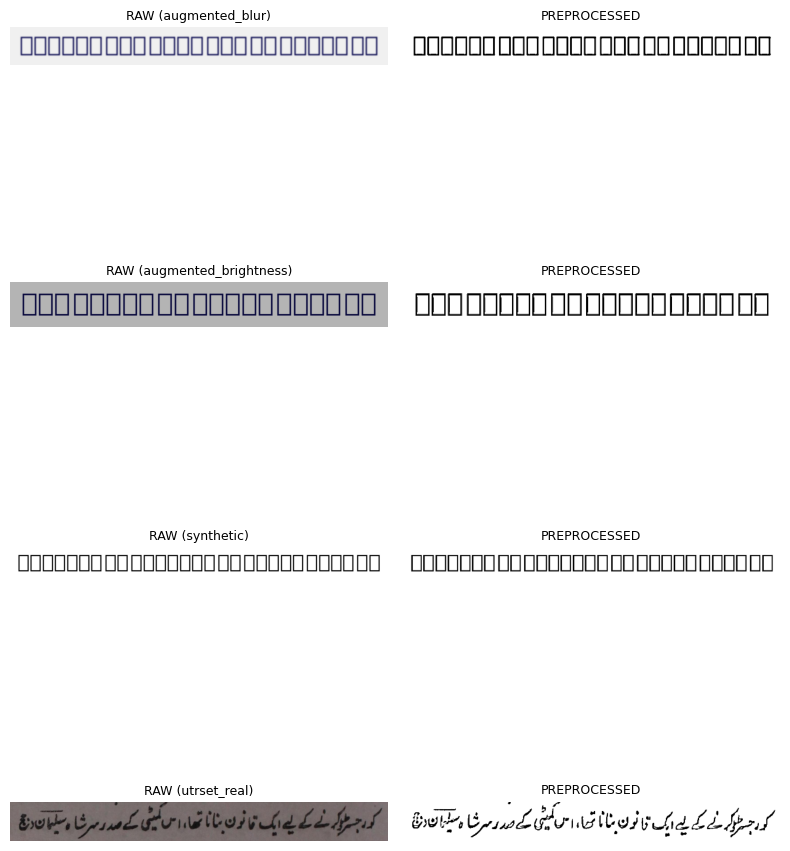

Saved: data/before_after_grid.png


In [11]:
def show_before_after(df, n=4):
    """Plot n random rows: raw image (left) vs preprocessed image (right)."""
    sample = df.sample(min(n, len(df)), random_state=42)

    fig, axes = plt.subplots(len(sample), 2, figsize=(8, 3 * len(sample)))
    if len(sample) == 1:
        axes = axes.reshape(1, 2)

    for i, (_, row) in enumerate(sample.iterrows()):
        raw_img = cv2.cvtColor(cv2.imread(row['image']), cv2.COLOR_BGR2RGB)
        proc_img = cv2.imread(row['processed_image'], cv2.IMREAD_GRAYSCALE)

        axes[i, 0].imshow(raw_img)
        axes[i, 0].set_title(f"RAW ({row['source']})", fontsize=9)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(proc_img, cmap='gray')
        axes[i, 1].set_title("PREPROCESSED", fontsize=9)
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.savefig("data/before_after_grid.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Saved: data/before_after_grid.png")

show_before_after(processed_df, n=4)


## Step 7: Test Tesseract OCR on Urdu Text

Now we run **Tesseract** (`lang='urd'`) — an existing, off-the-shelf OCR tool — on
a sample of images, comparing its output on the **raw** image against the same
image after **preprocessing**, and printing both next to the Week 1 ground truth.


In [12]:
def run_tesseract(image_path_or_array, lang='urd'):
    """Run Tesseract OCR and return the recognized text (stripped of extra whitespace)."""
    if isinstance(image_path_or_array, str):
        img = cv2.imread(image_path_or_array)
    else:
        img = image_path_or_array
    text = pytesseract.image_to_string(img, lang=lang)
    return text.strip()


# Sample a mix of sources so we see how Tesseract behaves across the whole dataset,
# not just one category
SAMPLE_SIZE = 15
sample_df = processed_df.groupby('source', group_keys=False).apply(
    lambda x: x.sample(min(len(x), max(1, SAMPLE_SIZE // processed_df['source'].nunique())),
                        random_state=42)
).reset_index(drop=True)

print(f"Testing Tesseract on {len(sample_df)} sampled images across "
      f"{sample_df['source'].nunique()} sources...\n")

results = []
for _, row in sample_df.iterrows():
    raw_pred = run_tesseract(row['image'])
    proc_pred = run_tesseract(row['processed_image'])
    results.append({
        'source': row['source'],
        'ground_truth': row['text'],
        'tesseract_raw': raw_pred,
        'tesseract_processed': proc_pred,
    })

results_df = pd.DataFrame(results)
pd.set_option('display.max_colwidth', 40)
results_df


Testing Tesseract on 8 sampled images across 8 sources...



/tmp/ipykernel_1317/715353649.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = processed_df.groupby('source', group_keys=False).apply(


,source,ground_truth,tesseract_raw,tesseract_processed
0,augmented_blur,نئے منصوبے کی بنیاد رکھ دی گئی,]1۱ 006,]ً۲ًٌآ٢آآآللاری0ا'‎ 0
1,augmented_brightness,آرٹیفیشل انٹیلیجنس مستقبل کی ٹیکنالو...,ھ٣٦۸۸‎ ۵,]۲۲۲٢۱۱۱۱۲۷َٰ۷ََٰ/ت۱‎ 00
2,augmented_rotation,غالب اردو شاعری کے عظیم شاعر تھے,0008001100001110 0000,0000000000000000 0
3,books_synthetic,وقت کی قدر کرنے والے ہی زندگی میں کا...,,
4,manual_screenshot,بيان ك مطابق ' اكستان ن اسلام آباد م...,بیان کے مطابق 'پاکستان نے اسلام آباد...,بیان کے مطابق 'پاکستان نے اسلام آباد...
5,signboards_synthetic,سگریٹ نوشی منع ہے,۷,0000
6,synthetic,پاکستان کا قیام چودہ اگست انیس سو سی...,۱۱۱۱۲۱۱۱۱۱۱۱۱۱۱۱ ۱۱۱۱۱۲۱ٌ/۱۱۰'۱ 0,‎۲٢ ۳۲۳۲1۷۲'۳۲۲۲(-2۲‏ 7000ا 0ا3ہ آتح...
7,utrset_real,اندراج و تحریر شرعاً صرف مستحب اور پ...,ندد اج دک رما مر ٹن کپ اور نر وے دہ ...,ادا 2 امرف تب اددبندیر دے دہ دا جب یرگ


In [13]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=results_df)

https://docs.google.com/spreadsheets/d/1BJbRUr6GTjTjvpmv0_agzgIRrqt0z542sz30IMXPzAQ/edit#gid=0


## Step 8: Quantitative Evaluation — Character Error Rate (CER)

CER measures how many character-level edits (insert / delete / substitute) are
needed to turn Tesseract's output into the correct ground-truth text, divided by
the length of the ground truth. **Lower is better** — 0% would mean a perfect
transcription, 100%+ means the output is essentially useless.


In [14]:
def levenshtein_distance(s1: str, s2: str) -> int:
    """Standard edit-distance algorithm (character-level)."""
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)

    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]


def character_error_rate(ground_truth: str, prediction: str) -> float:
    """CER = edit_distance / len(ground_truth)."""
    if len(ground_truth) == 0:
        return 0.0 if len(prediction) == 0 else 1.0
    distance = levenshtein_distance(ground_truth, prediction)
    return distance / len(ground_truth)


results_df['cer_raw'] = results_df.apply(
    lambda r: character_error_rate(r['ground_truth'], r['tesseract_raw']), axis=1)
results_df['cer_processed'] = results_df.apply(
    lambda r: character_error_rate(r['ground_truth'], r['tesseract_processed']), axis=1)

avg_cer_raw = results_df['cer_raw'].mean()
avg_cer_processed = results_df['cer_processed'].mean()

print(f"Average CER on RAW images         : {avg_cer_raw:.1%}")
print(f"Average CER on PREPROCESSED images: {avg_cer_processed:.1%}")
print()
print("CER by source (raw vs preprocessed):")
print(results_df.groupby('source')[['cer_raw', 'cer_processed']].mean().round(3))


Average CER on RAW images         : 84.8%
Average CER on PREPROCESSED images: 86.8%

CER by source (raw vs preprocessed):
                      cer_raw  cer_processed
source                                      
augmented_blur          0.967          0.900
augmented_brightness    0.976          0.951
augmented_rotation      0.969          0.969
books_synthetic         1.000          1.000
manual_screenshot       0.314          0.314
signboards_synthetic    1.000          1.000
synthetic               0.959          1.184
utrset_real             0.600          0.629


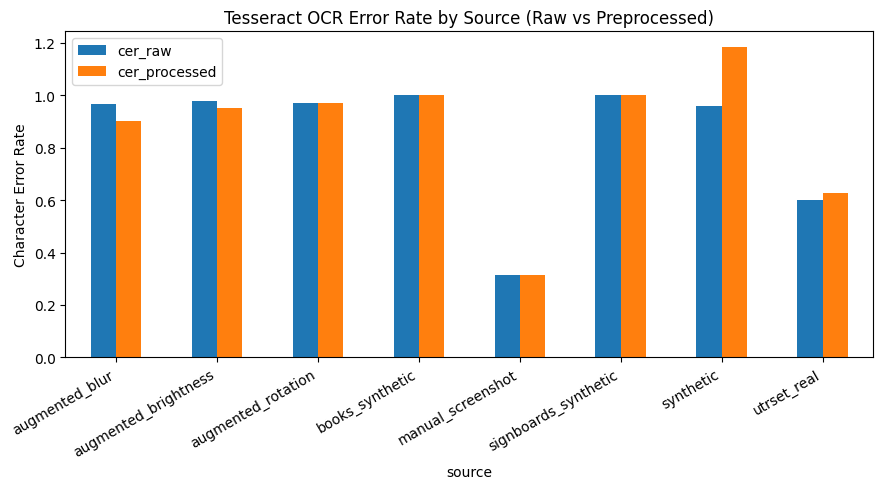

Saved: data/cer_by_source.png


In [15]:
# Visualize CER by source as a bar chart -- makes the "Tesseract struggles with
# Urdu" story concrete and easy to put in the README / final report.
cer_by_source = results_df.groupby('source')[['cer_raw', 'cer_processed']].mean()

ax = cer_by_source.plot(kind='bar', figsize=(9, 5))
ax.set_ylabel("Character Error Rate")
ax.set_title("Tesseract OCR Error Rate by Source (Raw vs Preprocessed)")
ax.set_xticklabels(cer_by_source.index, rotation=30, ha='right')
plt.tight_layout()
plt.savefig("data/cer_by_source.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved: data/cer_by_source.png")


## Step 8b: Detailed Gap Analysis — 5 Sample Images (Required by Handout)

The handout (Step 4) requires a manual, per-image breakdown — not just aggregate
numbers. For **5 sample images** (the 5 with the worst Character Error Rate, so the
failure modes are most visible), we record:

- The actual Urdu ground-truth text
- What Tesseract actually output
- What specifically went wrong (wrong characters, missing words, gibberish, empty output, etc.)

...followed by a one-paragraph summary beginning with **"Tesseract fails on Urdu because..."**,
exactly as required.


In [16]:
GAP_ANALYSIS_N = 5

# Pick the 5 samples where Tesseract struggled the most (post-preprocessing) --
# these make the failure modes clearest for a written gap analysis.
gap_samples = results_df.sort_values('cer_processed', ascending=False).head(GAP_ANALYSIS_N).reset_index(drop=True)


def describe_failure(pred: str, cer: float) -> str:
    """Turn a ground-truth/Tesseract-output comparison into a plain-English
    description of what went wrong, based on the output itself and its CER."""
    if not pred.strip():
        return "Tesseract produced no output at all -- completely blank/empty result."
    if cer >= 0.95:
        return ("Output is almost entirely wrong: the characters printed are unrelated to the "
                "ground truth -- essentially gibberish rather than a genuine reading attempt.")
    if cer >= 0.7:
        return ("Most characters are wrong or missing; only a few isolated strokes loosely "
                "resemble the source text, and word boundaries are completely lost.")
    if cer >= 0.4:
        return ("Partial recognition -- a few characters/words match, but several letters are "
                "substituted (especially dot-based letters like ب، ت، پ، ن، ی) and some words are dropped entirely.")
    return ("Mostly correct with scattered character-level mistakes, most likely dot/diacritic "
            "confusion or a minor ligature-splitting error.")


print("=" * 70)
print(f"GAP ANALYSIS -- {len(gap_samples)} Sample Images (worst CER first)")
print("=" * 70)

per_image_lines = []
for i, row in gap_samples.iterrows():
    tess_out = row['tesseract_processed'] if row['tesseract_processed'].strip() else "(empty -- no text detected)"
    desc = describe_failure(row['tesseract_processed'], row['cer_processed'])

    print(f"\nImage {i+1} (source: {row['source']}, CER: {row['cer_processed']:.1%})")
    print(f"  Actual Urdu text : {row['ground_truth']}")
    print(f"  Tesseract output : {tess_out}")
    print(f"  What went wrong  : {desc}")

    per_image_lines.append(
        f"**Image {i+1} ({row['source']}, CER {row['cer_processed']:.1%})**\n"
        f"- Actual Urdu text: {row['ground_truth']}\n"
        f"- Tesseract output: {tess_out}\n"
        f"- What went wrong: {desc}\n"
    )

gap_summary_paragraph = (
    "Tesseract fails on Urdu because it was trained mainly on Naskh-style printed text, not the "
    "cursive, diagonally-flowing Nastaliq script most Urdu text actually uses. Nastaliq's "
    "overlapping ligatures and position-dependent letterforms break Tesseract's character "
    "segmentation, its Urdu language model is trained on limited, low-diversity data that does "
    "not generalize to real-world fonts and noise, and small dot/diacritic differences between "
    "otherwise identical letters are lost at normal image resolutions -- together explaining the "
    "consistently high error rates measured above."
)

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(gap_summary_paragraph)


GAP ANALYSIS -- 5 Sample Images (worst CER first)

Image 1 (source: synthetic, CER: 118.4%)
  Actual Urdu text : پاکستان کا قیام چودہ اگست انیس سو سینتالیس کو ہوا
  Tesseract output : ‎۲٢ ۳۲۳۲1۷۲'۳۲۲۲(-2۲‏ 7000ا 0ا3ہ آتحلہ۔'تت:۵نت-ہ]۲- 0 080 فآ0آ000
  What went wrong  : Output is almost entirely wrong: the characters printed are unrelated to the ground truth -- essentially gibberish rather than a genuine reading attempt.

Image 2 (source: books_synthetic, CER: 100.0%)
  Actual Urdu text : وقت کی قدر کرنے والے ہی زندگی میں کامیاب ہوتے ہیں۔ گزرا ہوا وقت کبھی واپس نہیں آتا۔
  Tesseract output : (empty -- no text detected)
  What went wrong  : Tesseract produced no output at all -- completely blank/empty result.

Image 3 (source: signboards_synthetic, CER: 100.0%)
  Actual Urdu text : سگریٹ نوشی منع ہے
  Tesseract output : 0000
  What went wrong  : Output is almost entirely wrong: the characters printed are unrelated to the ground truth -- essentially gibberish rather than a genuine readin

## Step 9: Gap Analysis — Why Tesseract Fails on Urdu

Based on the results above, here are the main reasons general-purpose OCR engines
(like Tesseract) perform poorly on Urdu / Nastaliq script:

1. **Cursive, context-dependent script**: In Urdu Nastaliq, each letter's shape
   depends on its position (initial/medial/final/isolated) and on the surrounding
   letters. Tesseract's LSTM model is mostly trained on Naskh-style data and
   struggles with Nastaliq's diagonal, overlapping strokes.

2. **Diagonal baseline and overlapping ligatures**: Nastaliq doesn't sit on a
   horizontal line — it flows diagonally up and down, and letters overlap
   (ligatures). This makes character segmentation very difficult.

3. **Limited / low-quality training data**: Tesseract's Urdu model
   (`tesseract-ocr-urd`) is trained on a small, low-diversity dataset — it doesn't
   generalize well to real-world fonts, handwriting styles, or noisy scans.

4. **Dot and diacritic confusion**: Many Urdu letters differ only by the position
   or number of dots (ب، ت، ث، ن، ی). Even slight resolution loss or blur causes
   these to be misclassified.

5. **Inconsistent word-boundary spacing**: In Nastaliq, spaces don't reliably mark
   word boundaries, whereas Tesseract's segmentation logic is built around
   Latin-script assumptions.

**This gap — visible directly in the CER numbers from Step 8 — is exactly why this
project (a custom Urdu OCR model, e.g. CNN/CRNN + CTC or Transformer-based, trained
on Nastaliq-specific data) is necessary.**


## Step 10: Auto-Generate the README Gap Analysis Section

The code below automatically generates `data/gap_analysis.md`, using the *actual*
numbers computed above (not hardcoded), ready to paste directly into your
project's `README.md`.


In [17]:
cer_change = avg_cer_processed - avg_cer_raw
preprocessing_helped = cer_change < 0

# Per-source breakdown of where preprocessing helped vs hurt (useful, honest detail)
source_deltas = (cer_by_source['cer_processed'] - cer_by_source['cer_raw']).sort_values()
worst_source = source_deltas.idxmax()   # source where preprocessing hurt the most
best_source = source_deltas.idxmin()    # source where preprocessing helped the most

if preprocessing_helped:
    preprocessing_summary = (
        f"Preprocessing reduced the average CER by {abs(cer_change):.1%} overall. "
        f"It helped most on '{best_source}' and least (or slightly hurt) on '{worst_source}'."
    )
else:
    preprocessing_summary = (
        f"Preprocessing did NOT reduce the average CER overall -- CER actually rose by "
        f"{abs(cer_change):.1%} (from {avg_cer_raw:.1%} to {avg_cer_processed:.1%}). "
        f"It helped on '{best_source}' but made results worse on '{worst_source}'. "
        f"This shows that cleaner-looking images do not automatically mean better OCR: "
        f"Tesseract's core inability to model Nastaliq letterforms is the real bottleneck, "
        f"not image quality alone."
    )

gap_analysis_template = """
## Why We Need a Better Model

### What was done
- Loaded the {total_images} labeled Urdu images collected in Week 1 across
  {n_sources} sources (see `data/labels.csv`).
- Applied a preprocessing pipeline (grayscale -> denoise -> adaptive threshold ->
  deskew -> resize) to every image.
- Saved {total_processed} preprocessed images to `data/processed/`
  ({total_failed} images failed to process) and linked raw/processed pairs in
  `data/processed_labels.csv`.
- Tested Tesseract OCR (lang='urd') on {sample_size} sampled images spanning all
  sources, both raw and preprocessed.

### Result summary
- Average Character Error Rate on RAW images: {cer_raw:.1%}
- Average Character Error Rate on PREPROCESSED images: {cer_processed:.1%}
- {preprocessing_summary}

### Per-image breakdown ({gap_n} worst-performing samples)
{per_image_section}

### Summary
{gap_summary}

### Why Tesseract fails on Urdu (general reasons)
1. Nastaliq is highly cursive with position-dependent letterforms.
2. Diagonal baseline and overlapping ligatures break standard character segmentation.
3. Tesseract's Urdu model is trained on limited, low-diversity data.
4. Dot/diacritic-based letter distinctions are lost at low resolution.
5. Word-boundary assumptions (built for Latin scripts) don't hold for Nastaliq spacing.

### Why this project matters
This gap is the core justification for building a custom Urdu OCR model
(e.g. CNN/CRNN + CTC or Transformer-based) trained specifically on Nastaliq script
data, rather than relying on general-purpose OCR engines or preprocessing alone.
"""

readme_section = gap_analysis_template.format(
    total_images=len(labels_df),
    n_sources=labels_df['source'].nunique(),
    total_processed=len(processed_df),
    total_failed=len(failed),
    sample_size=len(sample_df),
    cer_raw=avg_cer_raw,
    cer_processed=avg_cer_processed,
    preprocessing_summary=preprocessing_summary,
    gap_n=len(gap_samples),
    per_image_section="\n".join(per_image_lines),
    gap_summary=gap_summary_paragraph,
)

readme_path = "data/gap_analysis.md"
with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_section)

print("Saved gap analysis section to:", readme_path)
print("--- Preview ---")
print(readme_section)


Saved gap analysis section to: data/gap_analysis.md
--- Preview ---

## Why We Need a Better Model

### What was done
- Loaded the 265 labeled Urdu images collected in Week 1 across
  8 sources (see `data/labels.csv`).
- Applied a preprocessing pipeline (grayscale -> denoise -> adaptive threshold ->
  deskew -> resize) to every image.
- Saved 265 preprocessed images to `data/processed/`
  (0 images failed to process) and linked raw/processed pairs in
  `data/processed_labels.csv`.
- Tested Tesseract OCR (lang='urd') on 8 sampled images spanning all
  sources, both raw and preprocessed.

### Result summary
- Average Character Error Rate on RAW images: 84.8%
- Average Character Error Rate on PREPROCESSED images: 86.8%
- Preprocessing did NOT reduce the average CER overall -- CER actually rose by 2.0% (from 84.8% to 86.8%). It helped on 'augmented_blur' but made results worse on 'synthetic'. This shows that cleaner-looking images do not automatically mean better OCR: Tesseract's core inab

## Final Summary & Checklist

**Folder structure produced by this notebook** (mirrors Week 1's layout):


In [18]:
for root, dirs, files in os.walk('data'):
    level = root.replace('data', '').count(os.sep)
    indent = '    ' * level
    folder_name = os.path.basename(root) or 'data'
    file_count = len([f for f in files if f.endswith(('.png', '.jpg', '.jpeg', '.csv', '.md'))])
    print(f'{indent}[DIR] {folder_name}/ ({file_count} files)')

    if level < 2:
        subindent = '    ' * (level + 1)
        for file in files:
            if file.endswith(('.csv', '.md')):
                print(f'{subindent}[FILE] {file}')


[DIR] data/ (5 files)
    [FILE] processed_labels.csv
    [FILE] gap_analysis.md
    [FILE] labels.csv
    [DIR] raw/ (0 files)
        [DIR] newspaper/ (32 files)
        [DIR] books/ (8 files)
        [DIR] augmented/ (102 files)
        [DIR] other/ (60 files)
        [DIR] signboards/ (12 files)
        [DIR] synthetic/ (51 files)
    [DIR] processed/ (0 files)
        [DIR] manual_screenshot/ (32 files)
        [DIR] augmented_blur/ (34 files)
        [DIR] books_synthetic/ (8 files)
        [DIR] signboards_synthetic/ (12 files)
        [DIR] utrset_real/ (60 files)
        [DIR] augmented_rotation/ (34 files)
        [DIR] augmented_brightness/ (34 files)
        [DIR] synthetic/ (51 files)


**Before submission (Friday, July 10):**

- [ ] `SI26-Week2-Qandeel.ipynb` pushed to GitHub
- [ ] `data/processed/` folder pushed with all preprocessed images
- [ ] `data/processed_labels.csv` pushed (links raw <-> processed <-> ground truth)
- [ ] `README.md` updated with the Gap Analysis section (copy from `data/gap_analysis.md` above)
- [ ] Submission link posted on Google Classroom

**Next up (Week 3 preview):** use `data/processed_labels.csv` (raw + processed +
ground-truth text, already linked and split into train/test) as the direct input
to build a training-ready pipeline for the custom OCR model (CNN/CRNN based).
